<a href="https://colab.research.google.com/github/Zinkal09/TOPS/blob/main/NLP_Sec_1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Section A

1. You load the Amazon Reviews dataset and find reviews stored as plain text strings. Why is text considered unstructured data compared to tabular data?

Text is considered unstructured data because it does not follow a predefined row-column format like tabular data. Natural language contains variable sentence structures, symbols, punctuation, and inconsistent patterns, making it harder for machines to process directly without NLP preprocessing.

2. You count unique words across all reviews to measure vocabulary size. What is a corpus in NLP terminology?

A corpus is a large collection of text documents used for NLP analysis and training.

A corpus helps:
analyze vocabulary
train ML models
detect language patterns
perform sentiment analysis

3.You print the top 20 most frequent words and find 'the', 'a', and 'is' dominate the list. What does this tell you about the usefulness of the most frequent words for sentiment analysis?

The dominance of words like 'the', 'a', and 'is' shows that the most frequent words are often stopwords, which carry little semantic or sentiment information. Although they appear frequently, they are generally not useful for sentiment analysis and are typically removed during preprocessing.


4.The NLP pipeline follows a fixed sequence of stages. List the stages of a standard NLP pipeline in order.

A standard NLP pipeline includes the following stages in order: data collection, text cleaning/preprocessing, tokenization, stopword removal, stemming or lemmatization, feature extraction/vectorization, model building, evaluation, and deployment.

5.You identify URLs, emojis, and symbols scattered across the reviews. At which stage of the NLP pipeline are these noisy patterns handled?

URLs, emojis, and symbols are handled during the text cleaning or preprocessing stage of the NLP pipeline.

Section B

1. Implement a custom regex-based tokenizer to isolate technical specifications and currency symbols from raw text

In [ ]:
import bz2
import pandas as pd

data = []

with bz2.open('/content/test.ft.txt.bz2', 'rt', encoding='utf-8') as file:
    for line in file:
        parts = line.split(' ', 1)

        label = parts[0]
        text = parts[1] if len(parts) > 1 else ""

        data.append([label, text])

df = pd.DataFrame(data, columns=['label', 'text'])

df.head()

,label,text
0,__label__2,Great CD: My lovely Pat has one of the GREAT v...
1,__label__2,One of the best game music soundtracks - for a...
2,__label__1,Batteries died within a year ...: I bought thi...
3,__label__2,"works fine, but Maha Energy is better: Check o..."
4,__label__2,Great for the non-audiophile: Reviewed quite a...


In [ ]:
import re

def custom_tokenizer(text):
  tech_pattern = r'\b\d+(?:GB|TB|MHz|Hz|mAh|inch|-inch)\b'
  currency_pattern =r'[₹$€£]\s?\d[\d,]*'

  tech_specs = re.findall(tech_pattern, text)
  currency_symbols = re.findall(currency_pattern, text)

  return tech_specs, currency_symbols # Return a tuple of two lists

In [ ]:
df['tech_specs'], df['currencies'] = zip(*df['text'].apply(custom_tokenizer))

In [ ]:
df[['text', 'tech_specs', 'currencies']].head()

In [ ]:
df[['text', 'tech_specs', 'currencies']].head(10)

,text,tech_specs,currencies
0,Great CD: My lovely Pat has one of the GREAT v...,[],[]
1,One of the best game music soundtracks - for a...,[],[]
2,Batteries died within a year ...: I bought thi...,[],[]
3,"works fine, but Maha Energy is better: Check o...",[],[]
4,Great for the non-audiophile: Reviewed quite a...,[],[]
5,DVD Player crapped out after one year: I also ...,[],[]
6,"Incorrect Disc: I love the style of this, but ...",[],[]
7,DVD menu select problems: I cannot scroll thro...,[],[]
8,Unique Weird Orientalia from the 1930's: Exoti...,[],[]
9,"Not an ""ultimate guide"": Firstly,I enjoyed the...",[],[]


In [ ]:
filtered_df = df[
    (df['tech_specs'].astype(str) != '[]') |
    (df['currencies'].astype(str) != '[]')
]

filtered_df[['text', 'tech_specs', 'currencies']].head(20)

,text,tech_specs,currencies
21,Dont like it: This product smells when you ope...,[],[$10]
37,Doublecharged for shipping because merchant wa...,[],[$9]
93,Mistake?: I ordered the Penguin edition for th...,[],"[$2, $15]"
135,Great product at a great price: A replacement ...,[],[$80]
141,If you're tempted to throw away $30....: I bou...,[],[$30]
142,Plug DOESN'T work with the iBook G4: This prod...,[12-inch],[]
192,Poor quality and high price... are these knock...,[],[$15]
219,I do not recommend this vacuum: We bought this...,[],[$400]
225,Absolutely great tripod for movie camera: exce...,[],[$400]
283,If you are a Nirvana fan this album is not for...,[],[$10]


2.  Perform N-gram analysis (Bigram/Trigram) to identify recurring product feature mentions in the Amazon corpus.

In [ ]:
from collections import Counter
from nltk.util import ngrams
from nltk.corpus import stopwords
import nltk

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stop_words = set(stopwords.words('english'))

In [ ]:
def preprocess(text):
  text = text.lower()
  text = re.sub(r'[^a-zA-Z\s]', '', text)

  words= text.split()
  words = [word for word in words if word not in stop_words]

  return words


In [ ]:
df['tokens'] = df['text'].apply(preprocess)

In [ ]:
all_bigrams = []

for tokens in df['tokens']:
    bigrams = list(ngrams(tokens, 2))
    all_bigrams.extend(bigrams)

In [ ]:
all_trigrams = []

for tokens in df['tokens']:
    trigrams = list(ngrams(tokens, 3))
    all_trigrams.extend(trigrams)

In [ ]:
bigram_freq = Counter(all_bigrams)

top_bigrams = bigram_freq.most_common(20)

print(top_bigrams)

[(('waste', 'money'), 9843), (('read', 'book'), 9731), (('would', 'recommend'), 8036), (('year', 'old'), 6755), (('one', 'best'), 6563), (('much', 'better'), 6460), (('dont', 'know'), 6404), (('highly', 'recommend'), 6281), (('waste', 'time'), 6051), (('dont', 'waste'), 5939), (('dont', 'buy'), 5738), (('great', 'book'), 5391), (('years', 'ago'), 5180), (('first', 'time'), 4899), (('even', 'though'), 4606), (('good', 'book'), 4171), (('ive', 'ever'), 3956), (('reading', 'book'), 3933), (('save', 'money'), 3929), (('long', 'time'), 3920)]


In [ ]:
trigram_freq = Counter(all_trigrams)

top_trigrams = trigram_freq.most_common(20)

print(top_trigrams)

[(('dont', 'waste', 'money'), 3613), (('dont', 'waste', 'time'), 1890), (('waste', 'time', 'money'), 1610), (('would', 'recommend', 'anyone'), 1081), (('would', 'highly', 'recommend'), 1076), (('would', 'recommend', 'book'), 1001), (('ive', 'ever', 'read'), 980), (('highly', 'recommend', 'book'), 956), (('recommend', 'book', 'anyone'), 939), (('ive', 'ever', 'seen'), 886), (('year', 'old', 'son'), 707), (('book', 'ever', 'read'), 702), (('dont', 'get', 'wrong'), 690), (('one', 'best', 'books'), 662), (('would', 'recommend', 'product'), 613), (('year', 'old', 'daughter'), 583), (('worth', 'every', 'penny'), 561), (('would', 'definitely', 'recommend'), 530), (('cant', 'go', 'wrong'), 519), (('book', 'well', 'written'), 488)]


3.Execute a Zipf’s Law validation by plotting log-rank vs log-frequency to analyze vocabulary distribution


“Zipf’s Law validation helps analyze vocabulary distribution in a text corpus. It demonstrates that a small number of words occur very frequently while most words occur rarely, which is a natural characteristic of human language and useful for NLP preprocessing and language modeling.”

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
all_words = []

for text in df['text']:

    words = preprocess(text)

    all_words.extend(words)

In [ ]:
word_freq = Counter(all_words)

In [ ]:
frequencies = sorted(
    word_freq.values(),
    reverse=True
)

In [ ]:
ranks = range(1, len(frequencies)+1)

In [ ]:
log_ranks = np.log10(ranks)

log_freqs = np.log10(frequencies)

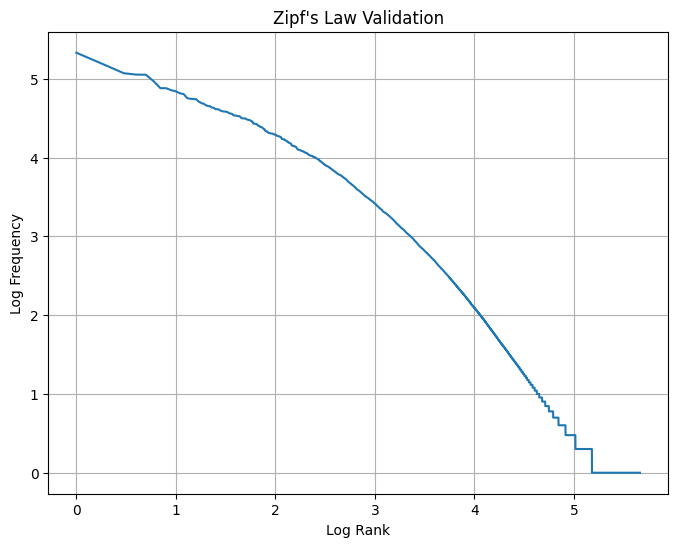

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(log_ranks, log_freqs)

plt.xlabel("Log Rank")

plt.ylabel("Log Frequency")

plt.title("Zipf's Law Validation")

plt.grid(True)

plt.show()

In [ ]:
import re
import pandas as pd

# Ensure stop_words is defined from previous steps
# If it's not, uncomment and run:
# import nltk
# from nltk.corpus import stopwords
# nltk.download('stopwords')
# stop_words = set(stopwords.words('english'))

def count_stopwords_and_informative_words(text):
    if not isinstance(text, str): # Handle non-string inputs if any
        return 0, 0
    text = text.lower()
    # Remove non-alphabetic characters but keep spaces for tokenization
    cleaned_text = re.sub(r'[^a-zA-Z\s]', '', text)

    # All words after basic cleaning
    all_words_in_text = cleaned_text.split()

    # Informative words (non-stopwords)
    informative_words = [word for word in all_words_in_text if word not in stop_words]

    # Stopwords
    stopwords_in_text = [word for word in all_words_in_text if word in stop_words]

    return len(stopwords_in_text), len(informative_words)

# Apply the function to the 'text' column to get counts
df[['stopwords_count', 'informative_words_count']] = df['text'].apply(
    lambda x: pd.Series(count_stopwords_and_informative_words(x))
)

# Calculate the ratio, handling division by zero
df['stopwords_to_informative_ratio'] = df.apply(
    lambda row: row['stopwords_count'] / row['informative_words_count'] if row['informative_words_count'] > 0 else 0,
    axis=1
)

# Group by 'label' (review category) and calculate the mean ratio
category_ratios = df.groupby('label')['stopwords_to_informative_ratio'].mean().reset_index()
category_ratios.columns = ['Review Category', 'Average Stopword to Informative Word Ratio']

print("Data Quality Auditor: Stopword to Informative Word Ratio per Review Category")
print(category_ratios)